# Project 1: Factors Affecting Log Wage (lwage)
## Regression Analysis

**Dataset**: wage.xlsx | **Target**: `lwage` | **Methods**: EDA · ANOVA · OLS · Ridge · Lasso

---

In [1]:
# ============================================================================
# CELL 0: IMPORTS AND CONFIGURATION
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
from scipy.stats import f_oneway
import os, warnings
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
sns.set_palette("husl")

print("Libraries loaded. Output -> figures/")


Libraries loaded. Output -> figures/


In [2]:
# ============================================================================
# CELL 1: LOAD AND PREPARE DATA
# ============================================================================
print("=" * 80)
print("PROJECT 1: FACTORS AFFECTING LOG WAGE - REGRESSION ANALYSIS")
print("=" * 80)

for _path in ['wage.xlsx', './wage.xlsx', 'data/wage.xlsx']:
    try:
        df_raw = pd.read_excel(_path)
        print(f"Loaded: {_path}  shape={df_raw.shape}")
        break
    except FileNotFoundError:
        continue
else:
    raise FileNotFoundError("wage.xlsx not found. Place it in the same folder as this notebook.")

SELECTED = ['lwage','educ','exper','expersq','IQ','KWW',
            'black','married','south','smsa','fatheduc','motheduc']
df = df_raw[SELECTED].copy()

VAR_DESC = {
    'lwage':'Log hourly wage (TARGET)', 'educ':'Years of education',
    'exper':'Years of experience', 'expersq':'Experience squared',
    'IQ':'IQ test score', 'KWW':'KWW score',
    'black':'Race (1=Black,0=other)', 'married':'Married (1=married,0=other)',
    'south':'Region (1=South,0=other)', 'smsa':'Urban (1=SMSA,0=rural)',
    'fatheduc':"Father's education (yrs)", 'motheduc':"Mother's education (yrs)"
}
print("\nVariable Descriptions:")
for v,d in VAR_DESC.items():
    print(f"  {v:<12} {d}")

print("\nMissing values:")
print(df.isnull().sum().to_string())

# Fix 'married': re-encode as binary if multi-category
uniq_m = sorted(df['married'].dropna().unique())
print(f"\n'married' unique values: {uniq_m}")
if len(uniq_m) > 2:
    df['married'] = (df['married'] == 1).astype(int)
    print("  -> Re-encoded: 1=currently married, 0=other")

n_before = len(df)
df = df.dropna()
n_after  = len(df)
print(f"\nCleaned: {n_after} obs  (dropped {n_before-n_after}, {(n_before-n_after)/n_before*100:.1f}%)")

print("\nBinary variables summary:")
for v in ['black','married','south','smsa']:
    print(f"  {v:<10}: {int(df[v].sum())} ({df[v].mean()*100:.1f}%) = 1")


PROJECT 1: FACTORS AFFECTING LOG WAGE - REGRESSION ANALYSIS
Loaded: wage.xlsx  shape=(3010, 34)

Variable Descriptions:
  lwage        Log hourly wage (TARGET)
  educ         Years of education
  exper        Years of experience
  expersq      Experience squared
  IQ           IQ test score
  KWW          KWW score
  black        Race (1=Black,0=other)
  married      Married (1=married,0=other)
  south        Region (1=South,0=other)
  smsa         Urban (1=SMSA,0=rural)
  fatheduc     Father's education (yrs)
  motheduc     Mother's education (yrs)

Missing values:
lwage         0
educ          0
exper         0
expersq       0
IQ          949
KWW          47
black         0
married       7
south         0
smsa          0
fatheduc    690
motheduc    353

'married' unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
  -> Re-encoded: 1=currently married, 0=other

Cleaned: 1604 obs  (dropped 1406, 46.7%)

Binary variables 

In [3]:
# ============================================================================
# CELL 2: EDA - DESCRIPTIVE STATISTICS
# ============================================================================
print("=" * 80)
print("2. EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

print("\n--- 2.1 DESCRIPTIVE STATISTICS ---")
desc = df.describe().T
desc['skewness'] = df.skew()
desc['kurtosis'] = df.kurtosis()
print(desc.round(4).to_string())

lw = df['lwage']
print("\n--- 2.2 TARGET VARIABLE: lwage ---")
print(f"  Mean      : {lw.mean():.4f}")
print(f"  Std       : {lw.std():.4f}")
print(f"  Median    : {lw.median():.4f}")
print(f"  Min/Max   : {lw.min():.4f} / {lw.max():.4f}")
print(f"  Skewness  : {lw.skew():.4f}")
print(f"  Kurtosis  : {lw.kurtosis():.4f}")

_, pnorm = stats.normaltest(lw)
print(f"  Normality test (D'Agostino-Pearson): p={pnorm:.4f}  {'Normal' if pnorm>0.05 else 'Non-normal'}")

corr_full = df.corr()
print("\n--- 2.3 CORRELATION WITH lwage (Pearson) ---")
print(corr_full['lwage'].drop('lwage').sort_values(ascending=False).round(4).to_string())


2. EXPLORATORY DATA ANALYSIS (EDA)

--- 2.1 DESCRIPTIVE STATISTICS ---
           count      mean      std      min      25%       50%      75%       max  skewness  kurtosis
lwage     1604.0    6.3426   0.4192   4.7185   6.0822    6.3682    6.607    7.7849   -0.2081    0.4501
educ      1604.0   14.1216   2.2658   8.0000  12.0000   14.0000   16.000   18.0000    0.1469   -1.1159
exper     1604.0    8.0542   3.6045   0.0000   6.0000    8.0000   10.000   19.0000    0.3824   -0.3148
expersq   1604.0   77.8547  65.0482   0.0000  36.0000   64.0000  100.000  361.0000    1.2853    1.2303
IQ        1604.0  103.8498  15.0028  53.0000  95.0000  105.0000  114.000  149.0000   -0.2902    0.1530
KWW       1604.0   35.9140   7.3824  13.0000  31.0000   36.0000   41.000   56.0000   -0.2287   -0.2101
black     1604.0    0.0998   0.2998   0.0000   0.0000    0.0000    0.000    1.0000    2.6738    5.1556
married   1604.0    0.7282   0.4450   0.0000   0.0000    1.0000    1.000    1.0000   -1.0267   -0.9470
so

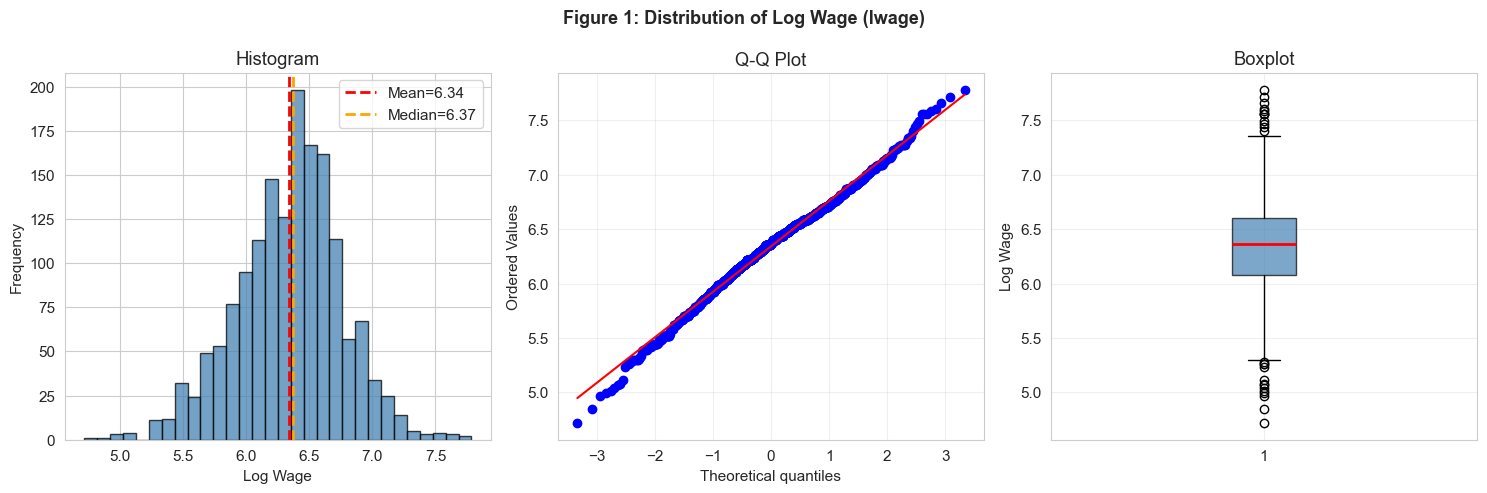

Figure 1 saved -> figures/fig1_lwage_distribution.png


In [4]:
# ============================================================================
# CELL 3: EDA VIZ - DISTRIBUTION OF lwage
# ============================================================================
lw = df['lwage']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 1: Distribution of Log Wage (lwage)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(lw, bins=30, edgecolor='black', alpha=0.75, color='steelblue')
ax.axvline(lw.mean(), color='red', lw=2, linestyle='--', label=f'Mean={lw.mean():.2f}')
ax.axvline(lw.median(), color='orange', lw=2, linestyle='--', label=f'Median={lw.median():.2f}')
ax.set_xlabel('Log Wage'); ax.set_ylabel('Frequency')
ax.set_title('Histogram'); ax.legend()

ax = axes[1]
stats.probplot(lw, dist='norm', plot=ax)
ax.set_title('Q-Q Plot'); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.boxplot(lw, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Log Wage'); ax.set_title('Boxplot'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig1_lwage_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Figure 1 saved -> figures/fig1_lwage_distribution.png")


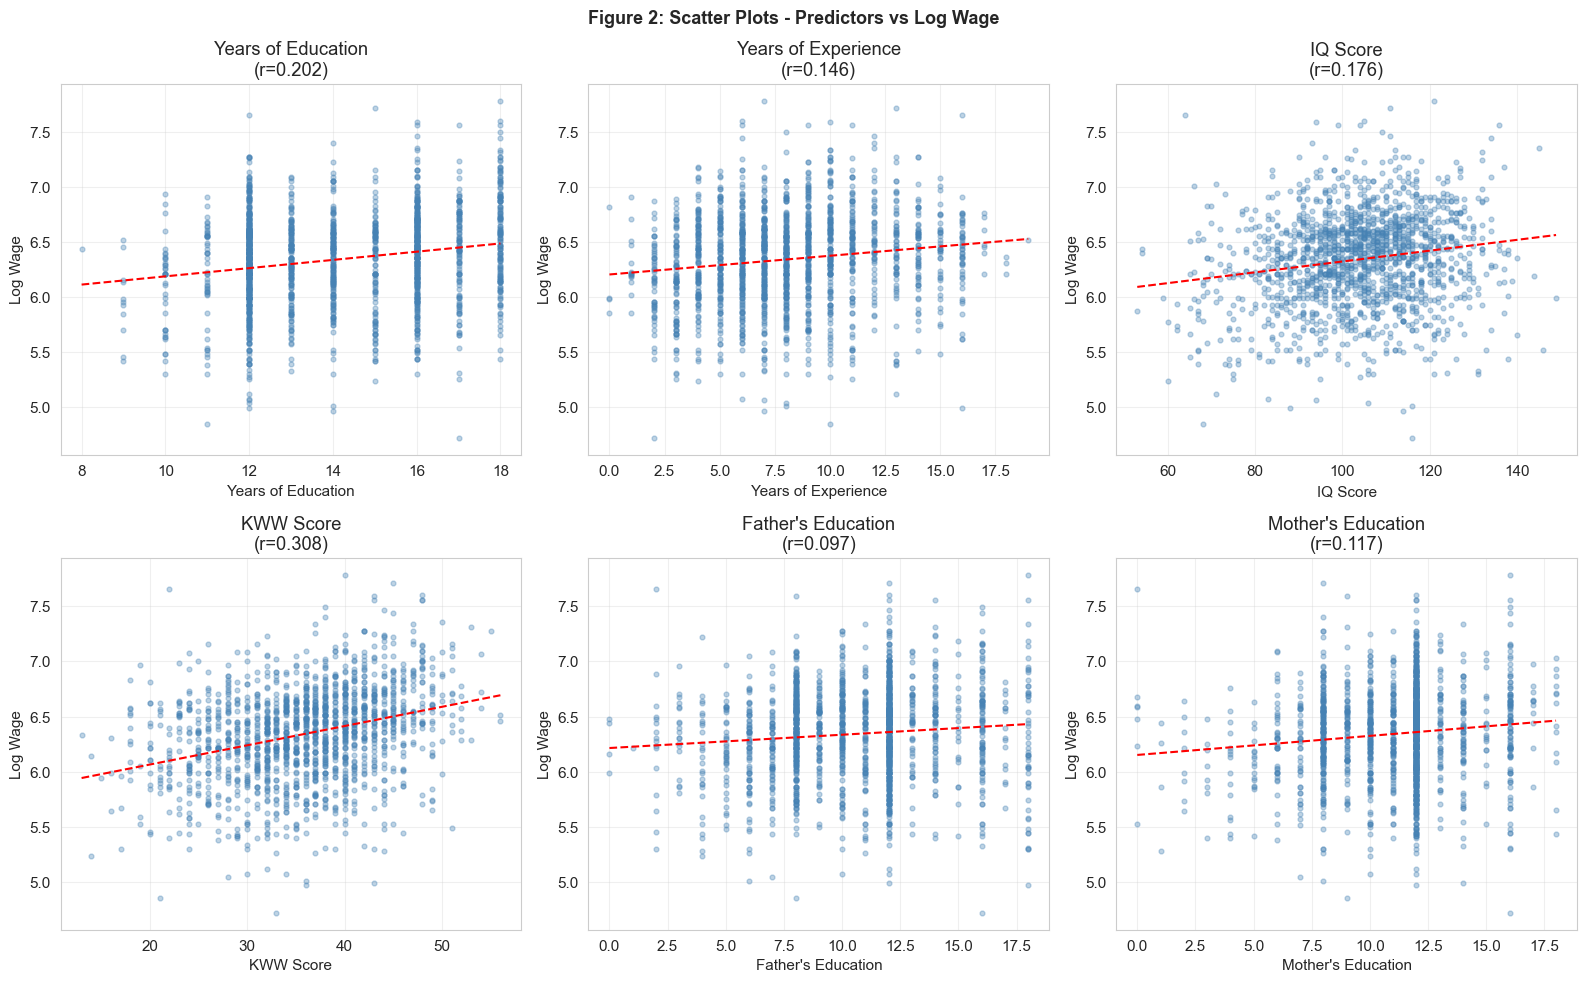

Figure 2 saved -> figures/fig2_scatter_plots.png


In [5]:
# ============================================================================
# CELL 4: EDA VIZ - SCATTER PLOTS (continuous predictors vs lwage)
# ============================================================================
CONT_VARS = [
    ('educ','Years of Education'), ('exper','Years of Experience'),
    ('IQ','IQ Score'), ('KWW','KWW Score'),
    ('fatheduc',"Father's Education"), ('motheduc',"Mother's Education"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Figure 2: Scatter Plots - Predictors vs Log Wage', fontsize=13, fontweight='bold')

for idx, (var, label) in enumerate(CONT_VARS):
    ax = axes[idx // 3, idx % 3]
    x_v, y_v = df[var], df['lwage']
    ax.scatter(x_v, y_v, alpha=0.35, s=12, color='steelblue')
    z = np.polyfit(x_v, y_v, 1)
    xl = np.linspace(x_v.min(), x_v.max(), 100)
    ax.plot(xl, np.poly1d(z)(xl), 'r--', lw=1.5)
    ax.set_xlabel(label); ax.set_ylabel('Log Wage')
    ax.set_title(f'{label}\n(r={x_v.corr(y_v):.3f})'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig2_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Figure 2 saved -> figures/fig2_scatter_plots.png")


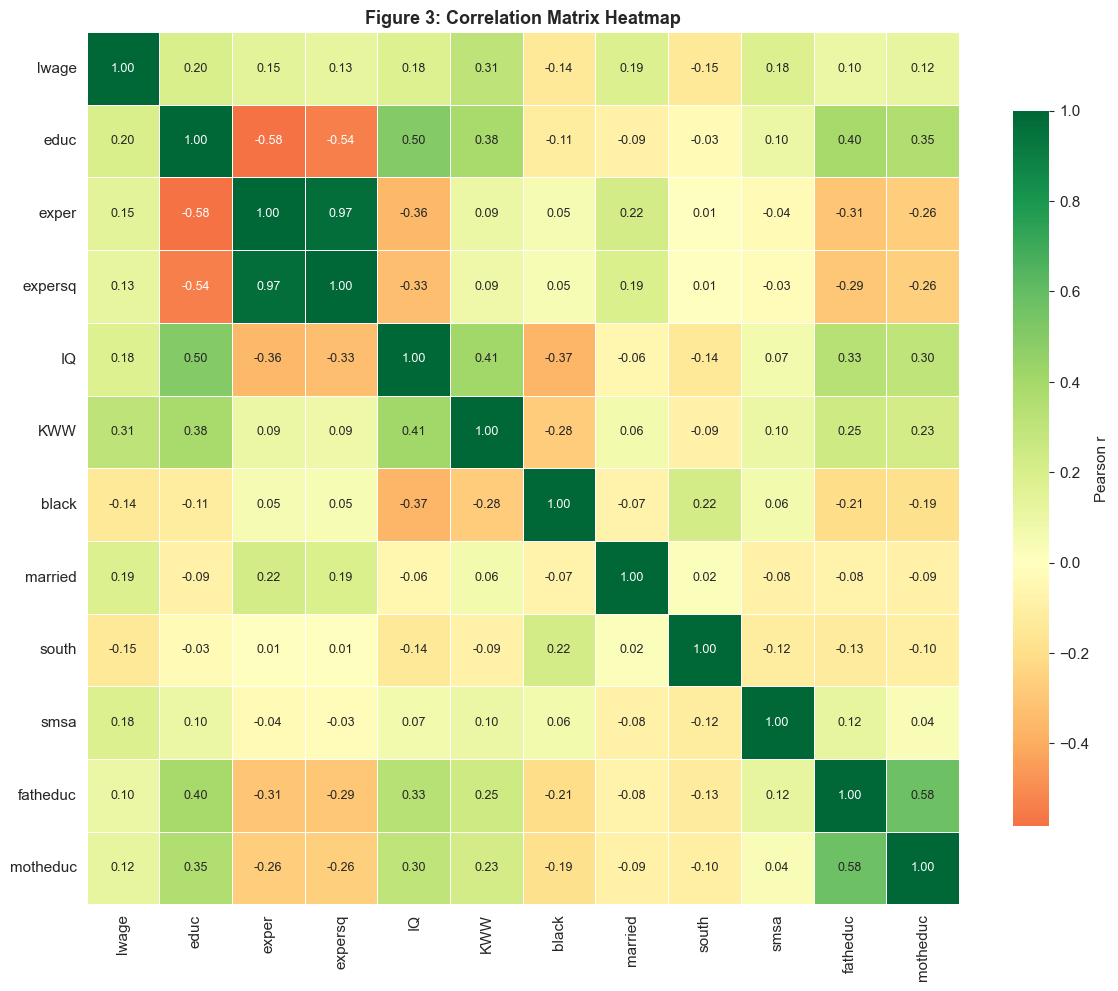

Figure 3 saved -> figures/fig3_correlation_heatmap.png

Note: expersq is highly correlated with exper (by construction) - monitor VIF.


In [6]:
# ============================================================================
# CELL 5: EDA VIZ - CORRELATION HEATMAP
# ============================================================================
corr_full = df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label':'Pearson r', 'shrink':0.8},
            annot_kws={'size':9})
ax.set_title('Figure 3: Correlation Matrix Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Figure 3 saved -> figures/fig3_correlation_heatmap.png")
print("\nNote: expersq is highly correlated with exper (by construction) - monitor VIF.")


3. ONE-WAY ANOVA
H0: Group means of lwage are equal   H1: At least one differs  (alpha=0.05)

--- ANOVA by Region (south) ---
  Non-South           : n=1076  mean=6.3860  std=0.4131
  South               : n= 528  mean=6.2540  std=0.4173
  F=35.9001  p=0.000000  -> Reject H0 - SIGNIFICANT

--- ANOVA by Race (black) ---
  Non-Black           : n=1444  mean=6.3627  std=0.4144
  Black               : n= 160  mean=6.1610  std=0.4178
  F=34.0383  p=0.000000  -> Reject H0 - SIGNIFICANT

--- ANOVA by Marital Status (married) ---
  Not Married         : n= 436  mean=6.2126  std=0.4390
  Married             : n=1168  mean=6.3911  std=0.4008
  F=59.6344  p=0.000000  -> Reject H0 - SIGNIFICANT

--- ANOVA by Area Type (smsa) ---
  Rural               : n= 402  mean=6.2088  std=0.3915
  Urban SMSA          : n=1202  mean=6.3873  std=0.4185
  F=56.4612  p=0.000000  -> Reject H0 - SIGNIFICANT


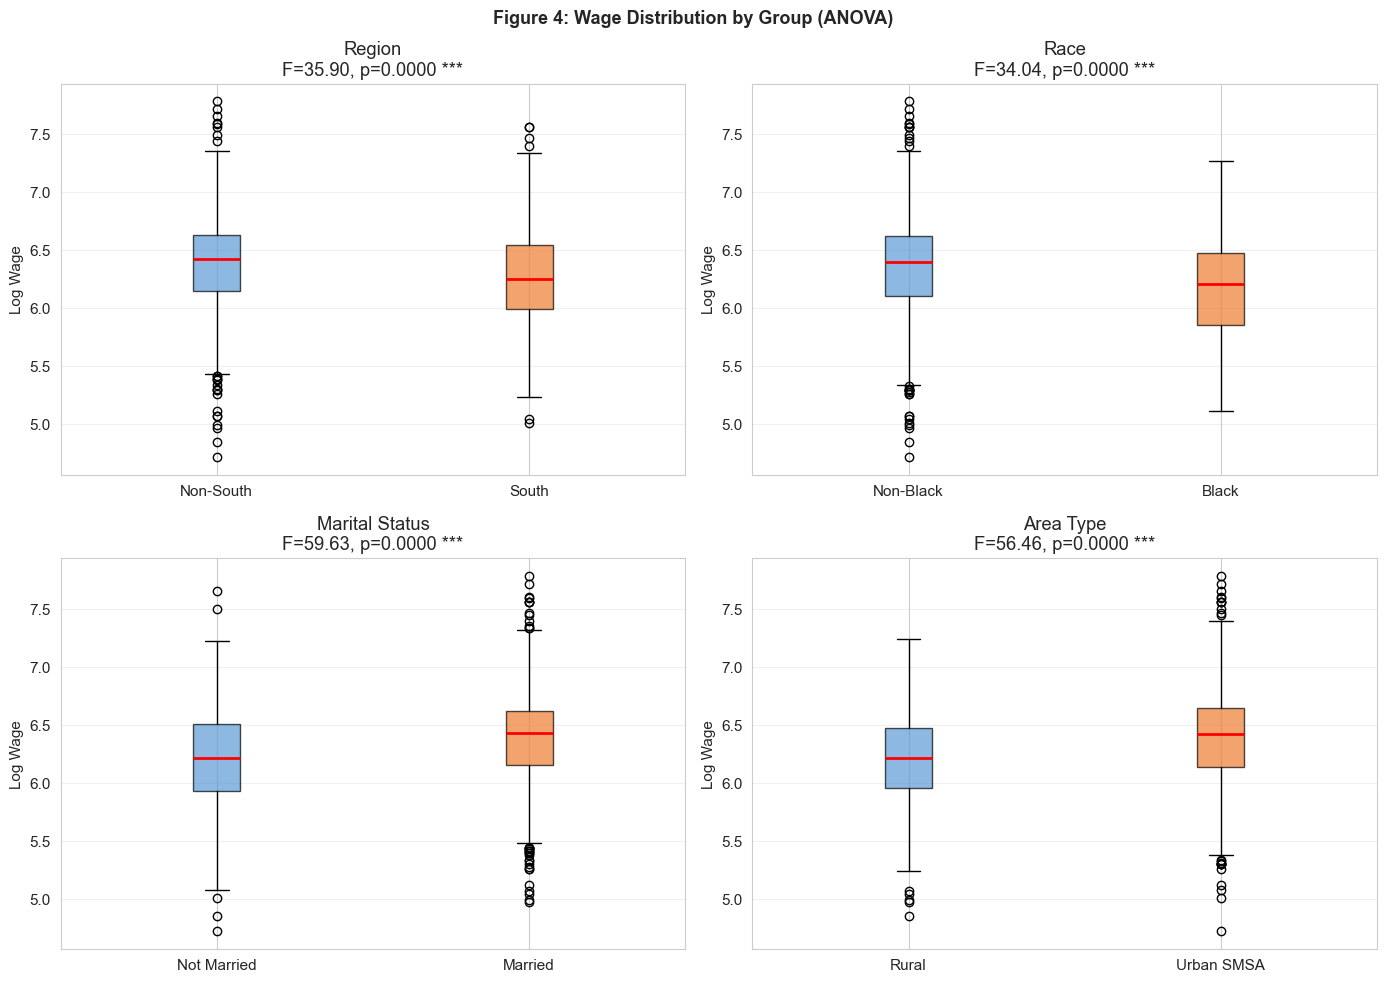


Figure 4 saved -> figures/fig4_anova.png


In [7]:
# ============================================================================
# CELL 6: ANOVA ANALYSIS
# ============================================================================
print("=" * 80)
print("3. ONE-WAY ANOVA")
print("=" * 80)
print("H0: Group means of lwage are equal   H1: At least one differs  (alpha=0.05)")

ANOVA_VARS = {
    'south'  : ('Region',         {0:'Non-South', 1:'South'}),
    'black'  : ('Race',           {0:'Non-Black',  1:'Black'}),
    'married': ('Marital Status', {0:'Not Married', 1:'Married'}),
    'smsa'   : ('Area Type',      {0:'Rural',       1:'Urban SMSA'}),
}

anova_results = {}
for var, (title, labels) in ANOVA_VARS.items():
    vals   = sorted(df[var].unique())
    groups = [df.loc[df[var]==v, 'lwage'].values for v in vals]
    f_s, p_v = f_oneway(*groups)
    anova_results[var] = (f_s, p_v)
    print(f"\n--- ANOVA by {title} ({var}) ---")
    for v, g in zip(vals, groups):
        print(f"  {labels[v]:<20}: n={len(g):4d}  mean={g.mean():.4f}  std={g.std():.4f}")
    sig = 'Reject H0 - SIGNIFICANT' if p_v < 0.05 else 'Fail to reject H0'
    print(f"  F={f_s:.4f}  p={p_v:.6f}  -> {sig}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 4: Wage Distribution by Group (ANOVA)', fontsize=13, fontweight='bold')

for idx, (var, (title, labels)) in enumerate(ANOVA_VARS.items()):
    ax = axes[idx // 2, idx % 2]
    vals   = sorted(df[var].unique())
    groups = [df.loc[df[var]==v, 'lwage'].values for v in vals]
    glbls  = [labels[v] for v in vals]
    bp = ax.boxplot(groups, labels=glbls, patch_artist=True,
                    medianprops=dict(color='red', linewidth=2))
    for patch, col in zip(bp['boxes'], ['#5B9BD5','#ED7D31']):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    f_v, p_v = anova_results[var]
    star = '***' if p_v<0.001 else '**' if p_v<0.01 else '*' if p_v<0.05 else 'n.s.'
    ax.set_ylabel('Log Wage')
    ax.set_title(f'{title}\nF={f_v:.2f}, p={p_v:.4f} {star}')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/fig4_anova.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("\nFigure 4 saved -> figures/fig4_anova.png")


In [8]:
# ============================================================================
# CELL 7: OLS REGRESSION - 3 MODELS
# ============================================================================
print("=" * 80)
print("4. OLS REGRESSION ANALYSIS")
print("=" * 80)

X_full = df[['educ','exper','expersq','IQ','KWW',
             'black','married','south','smsa','fatheduc','motheduc']]
y = df['lwage']
X_full_c = sm.add_constant(X_full)

# Model 1: Simple
print("\n" + "-"*80)
print("MODEL 1 - SIMPLE: educ + exper")
print("-"*80)
X1 = sm.add_constant(df[['educ','exper']])
model1 = sm.OLS(y, X1).fit()
print(model1.summary())

# Model 2: Extended
print("\n" + "-"*80)
print("MODEL 2 - EXTENDED: + expersq + IQ + KWW")
print("-"*80)
X2 = sm.add_constant(df[['educ','exper','expersq','IQ','KWW']])
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

# Model 3: Full
print("\n" + "-"*80)
print("MODEL 3 - FULL: all 11 predictors")
print("-"*80)
model3 = sm.OLS(y, X_full_c).fit()
print(model3.summary())


4. OLS REGRESSION ANALYSIS

--------------------------------------------------------------------------------
MODEL 1 - SIMPLE: educ + exper
--------------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     136.6
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.71e-55
Time:                        00:27:21   Log-Likelihood:                -754.69
No. Observations:                1604   AIC:                             1515.
Df Residuals:                    1601   BIC:                             1532.
Df Model:                           2                                         
Covariance Type:            nonrobust                               

In [9]:
# ============================================================================
# CELL 8: OLS MODEL COMPARISON, F-TESTS, CONFIDENCE INTERVALS
# ============================================================================
print("=" * 80)
print("5. OLS MODEL COMPARISON & HYPOTHESIS TESTING")
print("=" * 80)
n = len(y)

# 5.1 Comparison table
print("\n--- 5.1 MODEL FIT STATISTICS ---")
comp = pd.DataFrame({
    'Model 1 Simple'  : {'R2':model1.rsquared,'Adj.R2':model1.rsquared_adj,
                         'RMSE':np.sqrt(model1.mse_resid),'AIC':model1.aic,
                         'BIC':model1.bic,'F-stat':model1.fvalue,'F-pval':model1.f_pvalue},
    'Model 2 Extended': {'R2':model2.rsquared,'Adj.R2':model2.rsquared_adj,
                         'RMSE':np.sqrt(model2.mse_resid),'AIC':model2.aic,
                         'BIC':model2.bic,'F-stat':model2.fvalue,'F-pval':model2.f_pvalue},
    'Model 3 Full'    : {'R2':model3.rsquared,'Adj.R2':model3.rsquared_adj,
                         'RMSE':np.sqrt(model3.mse_resid),'AIC':model3.aic,
                         'BIC':model3.bic,'F-stat':model3.fvalue,'F-pval':model3.f_pvalue},
})
print(comp.round(4).to_string())

# 5.2 Incremental F-tests
ssr1 = (model1.resid**2).sum()
ssr2 = (model2.resid**2).sum()
ssr3 = (model3.resid**2).sum()

q_12 = 3; k2 = int(model2.df_model)+1
F_12 = ((ssr1-ssr2)/q_12) / (ssr2/(n-k2))
p_12 = 1 - stats.f.cdf(F_12, q_12, n-k2)

q_23 = 6; k3 = int(model3.df_model)+1
F_23 = ((ssr2-ssr3)/q_23) / (ssr3/(n-k3))
p_23 = 1 - stats.f.cdf(F_23, q_23, n-k3)

print("\n--- 5.2 INCREMENTAL F-TESTS ---")
print(f"H0: expersq, IQ, KWW jointly = 0   (M1 vs M2)")
print(f"  F({q_12},{n-k2})={F_12:.4f}  p={p_12:.6f}  -> {'Reject H0 - Model2 better' if p_12<0.05 else 'Fail to reject'}")
print(f"\nH0: black,married,south,smsa,fatheduc,motheduc jointly = 0   (M2 vs M3)")
print(f"  F({q_23},{n-k3})={F_23:.4f}  p={p_23:.6f}  -> {'Reject H0 - Model3 better' if p_23<0.05 else 'Fail to reject'}")

# 5.3 Confidence intervals (Model 3)
print("\n--- 5.3 95% CONFIDENCE INTERVALS - MODEL 3 ---")
ci = model3.conf_int(alpha=0.05)
ci.columns = ['CI_lower','CI_upper']
ct = pd.concat([model3.params.rename('Coef'), model3.bse.rename('StdErr'),
                model3.tvalues.rename('t-stat'), model3.pvalues.rename('p-value'), ci], axis=1)
print(ct.round(4).to_string())

# 5.4 Economic interpretation
print("\n--- 5.4 ECONOMIC INTERPRETATION (Model 3, ceteris paribus) ---")
INTERP = {
    'educ':'1 extra year of education',
    'exper':'1 extra year of experience',
    'IQ':'1 extra IQ point',
    'KWW':'1 extra KWW point',
    'black':'Being Black (vs other)',
    'married':'Being married (vs other)',
    'south':'Located in South (vs North)',
    'smsa':'Living in urban SMSA (vs rural)',
}
for var, desc in INTERP.items():
    c = model3.params[var]; p = model3.pvalues[var]
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    d = 'up' if c>0 else 'down'
    print(f"  {desc:<42}: lwage {d} {abs(c):.4f} (~{abs(c)*100:.2f}%)  {sig}")
print("  Significance: *** p<0.001  ** p<0.01  * p<0.05  n.s. p>=0.05")

b_exp = model3.params['exper']; b_exp2 = model3.params['expersq']
peak_exp = -b_exp/(2*b_exp2) if b_exp2 != 0 else float('nan')
print(f"\n  Peak experience (d.lwage/d.exper=0): {peak_exp:.1f} years")


5. OLS MODEL COMPARISON & HYPOTHESIS TESTING

--- 5.1 MODEL FIT STATISTICS ---
        Model 1 Simple  Model 2 Extended  Model 3 Full
R2              0.1458            0.1777        0.2371
Adj.R2          0.1447            0.1751        0.2318
RMSE            0.3877            0.3808        0.3674
AIC          1515.3723         1460.3277     1352.0356
BIC          1531.5130         1492.6093     1416.5986
F-stat        136.5820           69.0434       44.9716
F-pval          0.0000            0.0000        0.0000

--- 5.2 INCREMENTAL F-TESTS ---
H0: expersq, IQ, KWW jointly = 0   (M1 vs M2)
  F(3,1598)=20.6628  p=0.000000  -> Reject H0 - Model2 better

H0: black,married,south,smsa,fatheduc,motheduc jointly = 0   (M2 vs M3)
  F(6,1592)=20.6639  p=0.000000  -> Reject H0 - Model3 better

--- 5.3 95% CONFIDENCE INTERVALS - MODEL 3 ---
            Coef  StdErr   t-stat  p-value  CI_lower  CI_upper
const     4.4562  0.1194  37.3137   0.0000    4.2220    4.6904
educ      0.0603  0.0062   9.69

In [10]:
# ============================================================================
# CELL 9: MACHINE LEARNING MODELS
# ============================================================================
print("=" * 80)
print("6. MACHINE LEARNING MODELS")
print("=" * 80)

X_ml = df[['educ','exper','expersq','IQ','KWW',
           'black','married','south','smsa','fatheduc','motheduc']]
y_ml = df['lwage']

X_tr, X_te, y_tr, y_te = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)
print(f"Train: {len(X_tr)} obs ({len(X_tr)/len(X_ml)*100:.0f}%)")
print(f"Test : {len(X_te)} obs ({len(X_te)/len(X_ml)*100:.0f}%)")

scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

def eval_model(model, Xtr, Xte, ytr, yte, name):
    model.fit(Xtr, ytr)
    yh_tr = model.predict(Xtr); yh_te = model.predict(Xte)
    m = {
        'Train RMSE':np.sqrt(mean_squared_error(ytr,yh_tr)),
        'Test  RMSE':np.sqrt(mean_squared_error(yte,yh_te)),
        'Train MAE' :mean_absolute_error(ytr,yh_tr),
        'Test  MAE' :mean_absolute_error(yte,yh_te),
        'Train R2'  :r2_score(ytr,yh_tr),
        'Test  R2'  :r2_score(yte,yh_te),
    }
    print(f"\n  {name}")
    for k,v in m.items(): print(f"  {k:<14}: {v:.4f}")
    return m, model

m_lr, lr = eval_model(LinearRegression(), X_tr_sc, X_te_sc, y_tr, y_te,
                      "6.1 LINEAR REGRESSION")
cv_lr = cross_val_score(LinearRegression(), X_tr_sc, y_tr, cv=5, scoring='r2')
print(f"  CV R2 (5-fold): {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}")

alphas_g = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas_g, cv=5)
ridge_cv.fit(X_tr_sc, y_tr)
best_a_r = ridge_cv.alpha_
print(f"\n  Ridge best alpha (RidgeCV) = {best_a_r:.4f}")
m_ri, ri = eval_model(Ridge(alpha=best_a_r), X_tr_sc, X_te_sc, y_tr, y_te,
                      f"6.2 RIDGE REGRESSION (alpha={best_a_r:.4f})")
cv_ri = cross_val_score(Ridge(alpha=best_a_r), X_tr_sc, y_tr, cv=5, scoring='r2')
print(f"  CV R2 (5-fold): {cv_ri.mean():.4f} +/- {cv_ri.std():.4f}")

lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_tr_sc, y_tr)
best_a_l = lasso_cv.alpha_
print(f"\n  Lasso best alpha (LassoCV) = {best_a_l:.6f}")
m_la, la = eval_model(Lasso(alpha=best_a_l, max_iter=10000),
                      X_tr_sc, X_te_sc, y_tr, y_te,
                      f"6.3 LASSO REGRESSION (alpha={best_a_l:.6f})")
cv_la = cross_val_score(Lasso(alpha=best_a_l, max_iter=10000),
                         X_tr_sc, y_tr, cv=5, scoring='r2')
print(f"  CV R2 (5-fold): {cv_la.mean():.4f} +/- {cv_la.std():.4f}")

feat_df = pd.DataFrame({
    'Feature': X_ml.columns,
    'LR':  lr.coef_, 'Ridge': ri.coef_, 'Lasso': la.coef_,
}).sort_values('Lasso', key=abs, ascending=False)
print("\n  Standardized Coefficients:")
print(feat_df.round(4).to_string(index=False))
n_zero = (la.coef_ == 0).sum()
print(f"\n  Lasso eliminated {n_zero} variable(s) -> automatic feature selection")


6. MACHINE LEARNING MODELS
Train: 1283 obs (80%)
Test : 321 obs (20%)

  6.1 LINEAR REGRESSION
  Train RMSE    : 0.3683
  Test  RMSE    : 0.3596
  Train MAE     : 0.2835
  Test  MAE     : 0.2762
  Train R2      : 0.2344
  Test  R2      : 0.2252
  CV R2 (5-fold): 0.1998 +/- 0.0478

  Ridge best alpha (RidgeCV) = 3.2745

  6.2 RIDGE REGRESSION (alpha=3.2745)
  Train RMSE    : 0.3684
  Test  RMSE    : 0.3595
  Train MAE     : 0.2835
  Test  MAE     : 0.2759
  Train R2      : 0.2343
  Test  R2      : 0.2257
  CV R2 (5-fold): 0.2000 +/- 0.0470

  Lasso best alpha (LassoCV) = 0.000120

  6.3 LASSO REGRESSION (alpha=0.000120)
  Train RMSE    : 0.3683
  Test  RMSE    : 0.3595
  Train MAE     : 0.2834
  Test  MAE     : 0.2761
  Train R2      : 0.2344
  Test  R2      : 0.2255
  CV R2 (5-fold): 0.1998 +/- 0.0477

  Standardized Coefficients:
 Feature      LR   Ridge   Lasso
   exper  0.2801  0.2599  0.2754
 expersq -0.1545 -0.1361 -0.1502
    educ  0.1393  0.1370  0.1388
    smsa  0.0768  0.0764 

In [11]:
# ============================================================================
# CELL 10: ML MODEL COMPARISON TABLE
# ============================================================================
print("=" * 80)
print("7. ML MODEL COMPARISON")
print("=" * 80)

comp_ml = pd.DataFrame({'Linear':m_lr,'Ridge':m_ri,'Lasso':m_la}).T
comp_ml['CV R2 Mean'] = [cv_lr.mean(), cv_ri.mean(), cv_la.mean()]
comp_ml['CV R2 Std']  = [cv_lr.std(),  cv_ri.std(),  cv_la.std()]
print(comp_ml.round(4).to_string())

best_r2   = comp_ml['Test  R2'].idxmax()
best_rmse = comp_ml['Test  RMSE'].idxmin()
best_cv   = comp_ml['CV R2 Mean'].idxmax()
print(f"\n  Best Test R2      -> {best_r2}   ({comp_ml.loc[best_r2,'Test  R2']:.4f})")
print(f"  Lowest Test RMSE  -> {best_rmse}  ({comp_ml.loc[best_rmse,'Test  RMSE']:.4f})")
print(f"  Best CV R2        -> {best_cv}   ({comp_ml.loc[best_cv,'CV R2 Mean']:.4f})")


7. ML MODEL COMPARISON
        Train RMSE  Test  RMSE  Train MAE  Test  MAE  Train R2  Test  R2  CV R2 Mean  CV R2 Std
Linear      0.3683      0.3596     0.2835     0.2762    0.2344    0.2252      0.1998     0.0478
Ridge       0.3684      0.3595     0.2835     0.2759    0.2343    0.2257      0.2000     0.0470
Lasso       0.3683      0.3595     0.2834     0.2761    0.2344    0.2255      0.1998     0.0477

  Best Test R2      -> Ridge   (0.2257)
  Lowest Test RMSE  -> Ridge  (0.3595)
  Best CV R2        -> Ridge   (0.2000)


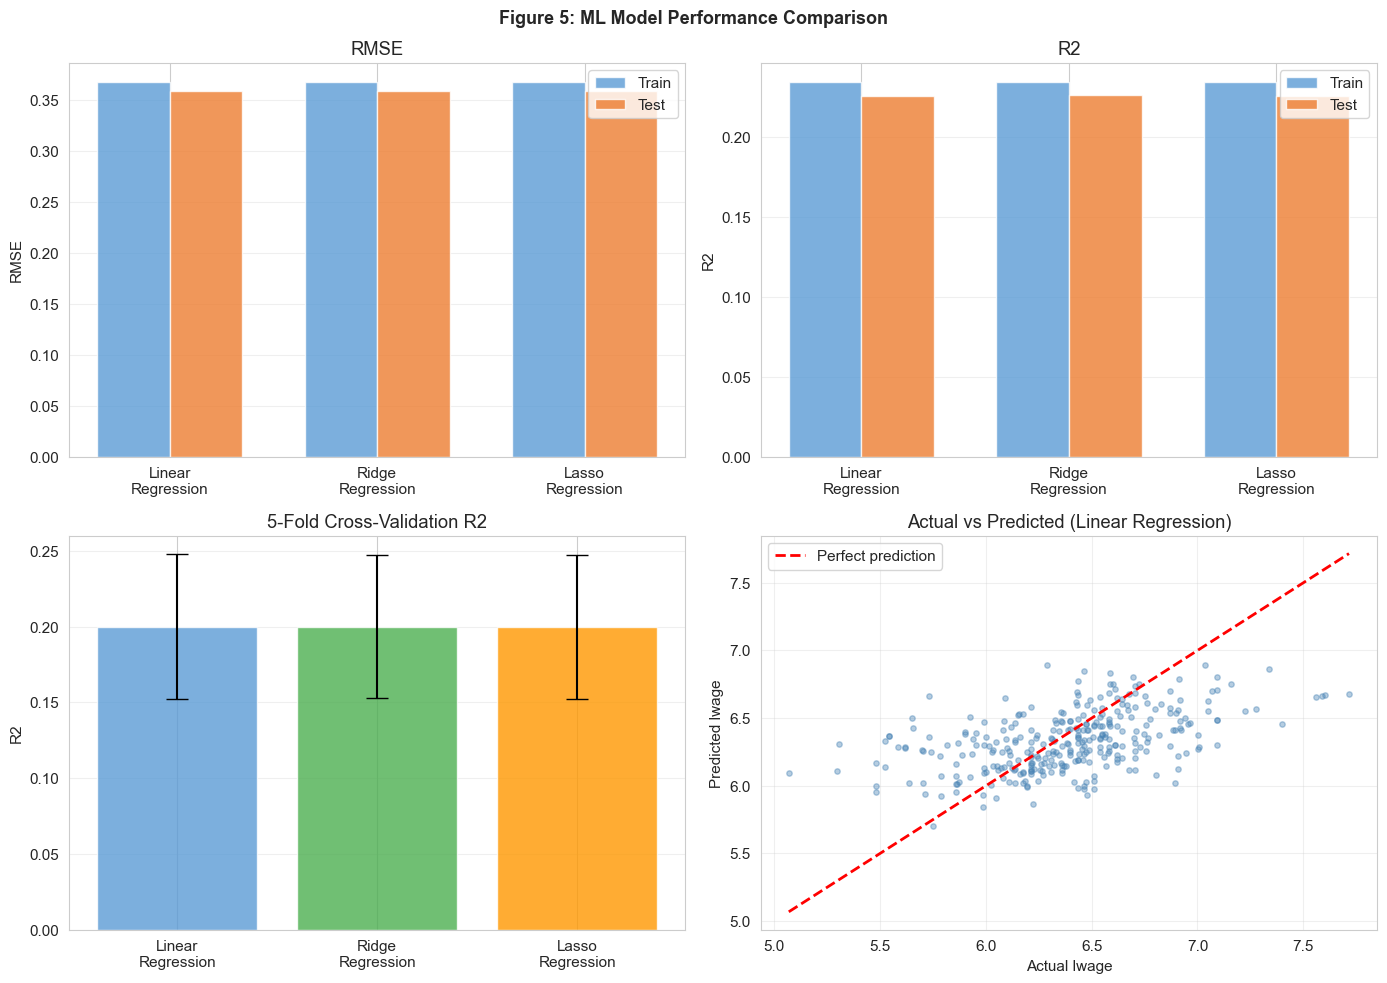

Figure 5 saved -> figures/fig5_ml_comparison.png


In [12]:
# ============================================================================
# CELL 11: ML VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 5: ML Model Performance Comparison', fontsize=13, fontweight='bold')

names = ['Linear\nRegression','Ridge\nRegression','Lasso\nRegression']
x_p = np.arange(3); w = 0.35
CT  = '#5B9BD5'; CE = '#ED7D31'

ax = axes[0,0]
ax.bar(x_p-w/2,[m_lr['Train RMSE'],m_ri['Train RMSE'],m_la['Train RMSE']],w,label='Train',color=CT,alpha=0.8)
ax.bar(x_p+w/2,[m_lr['Test  RMSE'],m_ri['Test  RMSE'],m_la['Test  RMSE']],w,label='Test', color=CE,alpha=0.8)
ax.set_xticks(x_p); ax.set_xticklabels(names)
ax.set_ylabel('RMSE'); ax.set_title('RMSE'); ax.legend(); ax.grid(axis='y',alpha=0.3)

ax = axes[0,1]
ax.bar(x_p-w/2,[m_lr['Train R2'],m_ri['Train R2'],m_la['Train R2']],w,label='Train',color=CT,alpha=0.8)
ax.bar(x_p+w/2,[m_lr['Test  R2'],m_ri['Test  R2'],m_la['Test  R2']],w,label='Test', color=CE,alpha=0.8)
ax.set_xticks(x_p); ax.set_xticklabels(names)
ax.set_ylabel('R2'); ax.set_title('R2'); ax.legend(); ax.grid(axis='y',alpha=0.3)

ax = axes[1,0]
cv_m = [cv_lr.mean(),cv_ri.mean(),cv_la.mean()]
cv_s = [cv_lr.std(), cv_ri.std(), cv_la.std()]
ax.bar(x_p,cv_m,yerr=cv_s,capsize=8,alpha=0.8,color=['#5B9BD5','#4CAF50','#FF9800'])
ax.set_xticks(x_p); ax.set_xticklabels(names)
ax.set_ylabel('R2'); ax.set_title('5-Fold Cross-Validation R2'); ax.grid(axis='y',alpha=0.3)

ax = axes[1,1]
yp = lr.predict(X_te_sc)
ax.scatter(y_te, yp, alpha=0.4, s=15, color='steelblue')
lo=min(y_te.min(),yp.min()); hi=max(y_te.max(),yp.max())
ax.plot([lo,hi],[lo,hi],'r--',lw=2,label='Perfect prediction')
ax.set_xlabel('Actual lwage'); ax.set_ylabel('Predicted lwage')
ax.set_title('Actual vs Predicted (Linear Regression)')
ax.legend(); ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig5_ml_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Figure 5 saved -> figures/fig5_ml_comparison.png")


In [13]:
# ============================================================================
# CELL 12: RESIDUAL DIAGNOSTICS
# ============================================================================
print("=" * 80)
print("8. MODEL DIAGNOSTICS - RESIDUAL ANALYSIS (Model 3)")
print("=" * 80)

resid = model3.resid

print("\n--- 8.1 NORMALITY TESTS ---")
sw_s, sw_p = stats.shapiro(resid[:5000])
ks_s, ks_p = stats.kstest((resid-resid.mean())/resid.std(), 'norm')
jb_s, jb_p = stats.jarque_bera(resid)
print(f"  Shapiro-Wilk (n={min(len(resid),5000)}) : W={sw_s:.4f}  p={sw_p:.6f}  -> {'Non-normal' if sw_p<0.05 else 'Normal'}")
print(f"  Kolmogorov-Smirnov         : D={ks_s:.4f}  p={ks_p:.6f}  -> {'Non-normal' if ks_p<0.05 else 'Normal'}")
print(f"  Jarque-Bera                : JB={jb_s:.4f}  p={jb_p:.6f}  -> {'Non-normal' if jb_p<0.05 else 'Normal'}")
print("  Note: Large samples often reject normality; inspect Q-Q plot for practical assessment.")

print("\n--- 8.2 HETEROSCEDASTICITY TESTS ---")
bp_lm, bp_p, _, _ = sm.stats.diagnostic.het_breuschpagan(resid, X_full_c)
wh_lm, wh_p, _, _ = sm.stats.diagnostic.het_white(resid, X_full_c)
print(f"  Breusch-Pagan : LM={bp_lm:.4f}  p={bp_p:.6f}  -> {'Heteroscedastic' if bp_p<0.05 else 'Homoscedastic'}")
print(f"  White Test    : LM={wh_lm:.4f}  p={wh_p:.6f}  -> {'Heteroscedastic' if wh_p<0.05 else 'Homoscedastic'}")
if bp_p < 0.05 or wh_p < 0.05:
    print("  Warning: Heteroscedasticity detected. Consider robust SE or WLS.")

print("\n--- 8.3 MULTICOLLINEARITY (VIF) ---")
vif_df = pd.DataFrame({
    'Feature': X_full.columns,
    'VIF': [variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_df.round(3).to_string(index=False))
print("  Guideline: VIF>10=severe, 5-10=moderate")
high_vif = vif_df[vif_df['VIF']>10]['Feature'].tolist()
print(f"  VIF>10 variables: {high_vif if high_vif else 'None'}")

dw_stat = durbin_watson(resid)
print(f"\n--- 8.4 DURBIN-WATSON ---")
print(f"  DW={dw_stat:.4f}  -> {'OK (no autocorrelation)' if 1.5<=dw_stat<=2.5 else 'Possible autocorrelation'}")


8. MODEL DIAGNOSTICS - RESIDUAL ANALYSIS (Model 3)

--- 8.1 NORMALITY TESTS ---
  Shapiro-Wilk (n=1604) : W=0.9900  p=0.000000  -> Non-normal
  Kolmogorov-Smirnov         : D=0.0469  p=0.001652  -> Non-normal
  Jarque-Bera                : JB=60.6483  p=0.000000  -> Non-normal
  Note: Large samples often reject normality; inspect Q-Q plot for practical assessment.

--- 8.2 HETEROSCEDASTICITY TESTS ---
  Breusch-Pagan : LM=25.7594  p=0.007046  -> Heteroscedastic
  White Test    : LM=122.8780  p=0.000176  -> Heteroscedastic

--- 8.3 MULTICOLLINEARITY (VIF) ---
 Feature    VIF
   exper 77.229
    educ 69.082
      IQ 62.771
     KWW 40.571
 expersq 34.225
motheduc 24.960
fatheduc 18.116
    smsa  4.207
 married  3.987
   south  1.594
   black  1.367
  Guideline: VIF>10=severe, 5-10=moderate
  VIF>10 variables: ['exper', 'educ', 'IQ', 'KWW', 'expersq', 'motheduc', 'fatheduc']

--- 8.4 DURBIN-WATSON ---
  DW=1.8608  -> OK (no autocorrelation)


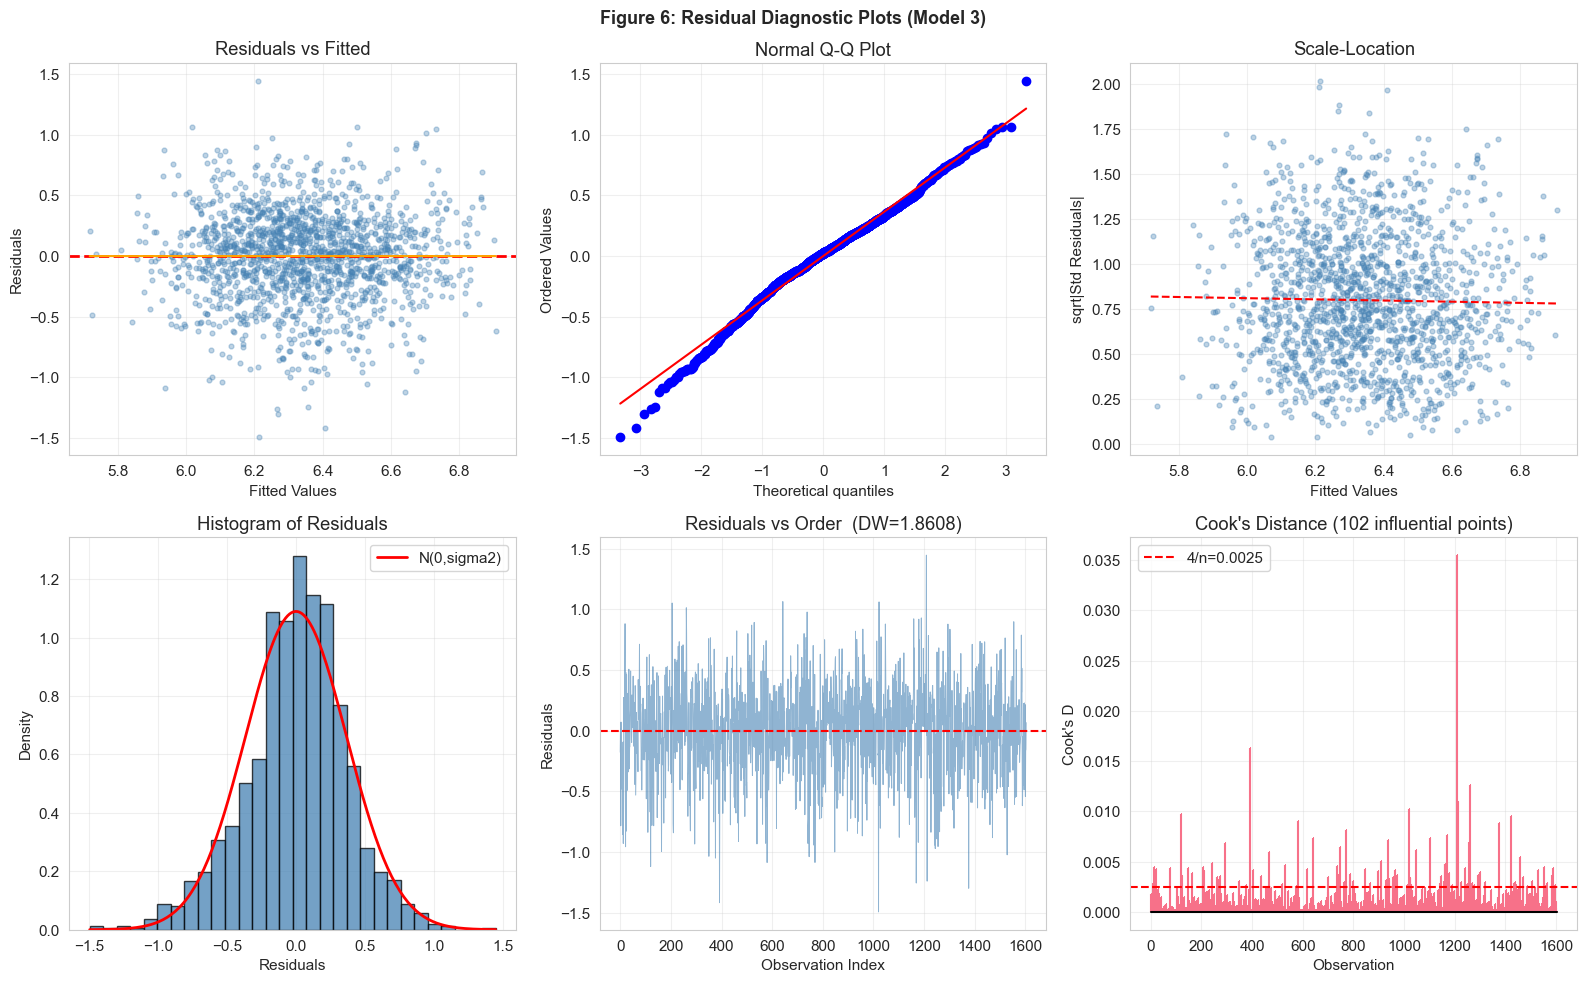

Figure 6 saved -> figures/fig6_residual_diagnostics.png


In [14]:
# ============================================================================
# CELL 13: RESIDUAL DIAGNOSTIC PLOTS
# ============================================================================
resid      = model3.resid
std_resid  = (resid - resid.mean()) / resid.std()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Figure 6: Residual Diagnostic Plots (Model 3)', fontsize=13, fontweight='bold')

ax = axes[0,0]
ax.scatter(model3.fittedvalues, resid, alpha=0.35, s=12, color='steelblue')
ax.axhline(0, color='r', lw=2, linestyle='--')
z = np.polyfit(model3.fittedvalues, resid, 1)
xs = np.sort(model3.fittedvalues)
ax.plot(xs, np.poly1d(z)(xs), 'orange', lw=1.5)
ax.set_xlabel('Fitted Values'); ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted'); ax.grid(True, alpha=0.3)

ax = axes[0,1]
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Normal Q-Q Plot'); ax.grid(True, alpha=0.3)

ax = axes[0,2]
ax.scatter(model3.fittedvalues, np.sqrt(np.abs(std_resid)), alpha=0.35, s=12, color='steelblue')
z = np.polyfit(model3.fittedvalues, np.sqrt(np.abs(std_resid)), 1)
xs = np.sort(model3.fittedvalues)
ax.plot(xs, np.poly1d(z)(xs), 'r--', lw=1.5)
ax.set_xlabel('Fitted Values'); ax.set_ylabel('sqrt|Std Residuals|')
ax.set_title('Scale-Location'); ax.grid(True, alpha=0.3)

ax = axes[1,0]
ax.hist(resid, bins=30, edgecolor='black', alpha=0.75, color='steelblue', density=True)
xr = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xr, stats.norm.pdf(xr, resid.mean(), resid.std()), 'r-', lw=2, label='N(0,sigma2)')
ax.set_xlabel('Residuals'); ax.set_ylabel('Density')
ax.set_title('Histogram of Residuals'); ax.legend(); ax.grid(True, alpha=0.3)

dw_stat = durbin_watson(resid)
ax = axes[1,1]
ax.plot(resid.values, alpha=0.6, lw=0.7, color='steelblue')
ax.axhline(0, color='r', lw=1.5, linestyle='--')
ax.set_xlabel('Observation Index'); ax.set_ylabel('Residuals')
ax.set_title(f'Residuals vs Order  (DW={dw_stat:.4f})')
ax.grid(True, alpha=0.3)

ax = axes[1,2]
influence = model3.get_influence()
cooks_d   = influence.cooks_distance[0]
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=',', linefmt='C0-', basefmt='k-')
thr = 4 / len(resid)
ax.axhline(thr, color='r', ls='--', lw=1.5, label=f'4/n={thr:.4f}')
n_inf = (cooks_d > thr).sum()
ax.set_xlabel('Observation'); ax.set_ylabel("Cook's D")
ax.set_title(f"Cook's Distance ({n_inf} influential points)")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig6_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Figure 6 saved -> figures/fig6_residual_diagnostics.png")


In [15]:
# ============================================================================
# CELL 14: SUMMARY AND CONCLUSIONS
# ============================================================================
print("\n" + "=" * 80)
print("9. SUMMARY AND CONCLUSIONS")
print("=" * 80)

SEP = "-" * 78

print("\nDATASET")
print(f"  Observations : {len(df)}")
print(f"  Variables    : {len(df.columns)}")
print(f"  Target       : lwage (log hourly wage)")
print(f"  Mean lwage   : {df['lwage'].mean():.4f}  std={df['lwage'].std():.4f}")

print("\n" + SEP)
print("1. EDA FINDINGS")
print(SEP)
print(f"  lwage approximately normal  skewness={df['lwage'].skew():.3f}")
print(f"  Top correlations with lwage: KWW, educ, smsa")
print(f"  ANOVA results (alpha=0.05): all four group variables significant")

print("\n" + SEP)
print("2. OLS REGRESSION")
print(SEP)
print(f"  Model 1 Simple   R2={model1.rsquared:.4f} Adj.R2={model1.rsquared_adj:.4f} RMSE={np.sqrt(model1.mse_resid):.4f}")
print(f"  Model 2 Extended R2={model2.rsquared:.4f} Adj.R2={model2.rsquared_adj:.4f} RMSE={np.sqrt(model2.mse_resid):.4f}")
print(f"  Model 3 Full     R2={model3.rsquared:.4f} Adj.R2={model3.rsquared_adj:.4f} RMSE={np.sqrt(model3.mse_resid):.4f}")
r12 = 'Model 2 significantly better' if p_12<0.05 else 'Not significant'
r23 = 'Model 3 significantly better' if p_23<0.05 else 'Not significant'
print(f"  F-test M1 vs M2: p={p_12:.4f}  -> {r12}")
print(f"  F-test M2 vs M3: p={p_23:.4f}  -> {r23}")
print(f"\n  Key findings (Model 3, ceteris paribus):")
print(f"  + Education  +1yr  -> +{model3.params['educ']*100:.2f}% wage  p={model3.pvalues['educ']:.4f}")
print(f"  + Experience inverted-U (peak ~{peak_exp:.1f} yrs)")
print(f"  + IQ         +1pt  -> +{model3.params['IQ']*100:.3f}% wage  p={model3.pvalues['IQ']:.4f}")
print(f"  + Black      penalty {abs(model3.params['black'])*100:.2f}%  p={model3.pvalues['black']:.4f}")
print(f"  + South      penalty {abs(model3.params['south'])*100:.2f}%  p={model3.pvalues['south']:.4f}")
print(f"  + SMSA       premium {model3.params['smsa']*100:.2f}%  p={model3.pvalues['smsa']:.4f}")

print("\n" + SEP)
print("3. MACHINE LEARNING MODELS")
print(SEP)
print(f"  Linear  TestR2={m_lr['Test  R2']:.4f} RMSE={m_lr['Test  RMSE']:.4f} CV={cv_lr.mean():.4f}+/-{cv_lr.std():.4f}")
print(f"  Ridge   TestR2={m_ri['Test  R2']:.4f} RMSE={m_ri['Test  RMSE']:.4f} CV={cv_ri.mean():.4f}+/-{cv_ri.std():.4f} alpha={best_a_r:.4f}")
print(f"  Lasso   TestR2={m_la['Test  R2']:.4f} RMSE={m_la['Test  RMSE']:.4f} CV={cv_la.mean():.4f}+/-{cv_la.std():.4f} alpha={best_a_l:.6f}")
print(f"  Lasso eliminated {(la.coef_==0).sum()} variable(s)")

print("\n" + SEP)
print("4. DIAGNOSTICS")
print(SEP)
h_r = 'Detected -> consider robust SE or WLS' if bp_p<0.05 else 'Not detected OK'
v_r = 'VIF>10: '+str(high_vif) if high_vif else 'No severe multicollinearity OK'
d_r = 'OK' if 1.5<=dw_stat<=2.5 else 'Check autocorrelation'
print(f"  Heteroscedasticity : {h_r}")
print(f"  Multicollinearity  : {v_r}")
print(f"  Durbin-Watson      : {dw_stat:.4f} -> {d_r}")

print("\n" + SEP)
print("5. RECOMMENDATIONS")
print(SEP)
print("  * Use HC3 robust SE if heteroscedasticity is confirmed")
print("  * Consider interaction term educ x exper")
print("  * Ridge/Lasso provide more stable predictions than plain OLS")
print(f"  * Model explains ~{model3.rsquared*100:.1f}% of wage variation")
print("    Omitted: occupation, industry, firm size")

print("\n" + "=" * 80)
print("PROJECT 1 COMPLETE")
print("=" * 80)
print("\nFigures saved in: figures/")
for fn in sorted(os.listdir('figures')):
    print(f"  {fn}")



9. SUMMARY AND CONCLUSIONS

DATASET
  Observations : 1604
  Variables    : 12
  Target       : lwage (log hourly wage)
  Mean lwage   : 6.3426  std=0.4192

------------------------------------------------------------------------------
1. EDA FINDINGS
------------------------------------------------------------------------------
  lwage approximately normal  skewness=-0.208
  Top correlations with lwage: KWW, educ, smsa
  ANOVA results (alpha=0.05): all four group variables significant

------------------------------------------------------------------------------
2. OLS REGRESSION
------------------------------------------------------------------------------
  Model 1 Simple   R2=0.1458 Adj.R2=0.1447 RMSE=0.3877
  Model 2 Extended R2=0.1777 Adj.R2=0.1751 RMSE=0.3808
  Model 3 Full     R2=0.2371 Adj.R2=0.2318 RMSE=0.3674
  F-test M1 vs M2: p=0.0000  -> Model 2 significantly better
  F-test M2 vs M3: p=0.0000  -> Model 3 significantly better

  Key findings (Model 3, ceteris paribus):
 